<a href="https://colab.research.google.com/github/Semere-Mesfin-Gebresilassie/Semere-Mesfin-Gebresilassie/blob/main/Faculty_Survey_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:

# Employer/Stakeholder Survey Data Analysis
# BSc Civil Engineering Curriculum Review

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
from google.colab import files
uploaded = files.upload()
print(uploaded)

Saving Faculty.xlsx to Faculty (1).xlsx
{'Faculty (1).xlsx': b'PK\x03\x04\n\x00\x00\x00\x00\x00\x87N\xe2@\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\t\x00\x00\x00docProps/PK\x03\x04\x14\x00\x00\x00\x08\x00\x87N\xe2@x}\xc1~/\x01\x00\x005\x02\x00\x00\x10\x00\x00\x00docProps/app.xml\x9d\x91\xc1J\x031\x10\x86\xef\x82\xef\x10ro\xb3-"RvS\x04)\xde\\h\xd5s\xcc\xce\xb6\x81\xdd$d\xa6K\xeb\xb3x\xf1 \xf8\x06\x9e|\x1b\x05\x1f\xc3\xec.\xe8V=y\x9b\x99\xff\xe7\xcf\xf7\x93t\xbe\xab+\xd6@@\xe3l\xc6\'\xe3\x843\xb0\xda\x15\xc6\xae3~\xbdZ\x8c\xce8CR\xb6P\x95\xb3\x90\xf1= \x9f\xcb\xe3\xa34\x0f\xceC \x03\xc8b\x84\xc5\x8co\x88\xfcL\x08\xd4\x1b\xa8\x15\x8e\xa3l\xa3R\xbaP+\x8akX\x0bW\x96F\xc3\x85\xd3\xdb\x1a,\x89i\x92\x9c\n\xd8\x11\xd8\x02\x8a\x91\xff\n\xe4}\xe2\xac\xa1\xff\x86\x16N\xb7|x\xb3\xda\xfb\x08,\xd3s\xef+\xa3\x15\xc5\x96\xf26_\xb2\xe5\x06\x800\x15\xc3{z\t\xaa\xed\x9d+\x13P\xa6\r\xcd\x1a\xd0\xe4\x02Cs\x1f\x9bO9\xbbS\x08mb\xc6\x1b\x15\x8c\xb2\x14\x93[[\xbfts\xe5\x91\x82|\x7fyz{}\xf8x|NE\xd4\xfb[7\x

In [35]:

# 1. Load and Prepare Data

# Define the column names based on the structure observed in the Excel file.
# (Manually extracted from the header row; indices 0 to 68 as per the markdown.)
column_names = [
    "empty",                         # 0: empty column
    "data_collector",                # 1: Full Name of Data Collector
    "stakeholder",                   # 2: Please select The Stockholder of the Target Interview
    "needs_assessment_text",          # 3: Long description (can be ignored)
    "purpose_survey",                 # 4: PURPOSE OF THE SURVEY
    "academic_rank",                  # 5: 1. Academic rank
    "specialization",                 # 6: 2. Area of specialization
    "experience_years",               # 7: 3. Teaching Experience in Years
    "rate_header1",                   # 8: "4. Rate the following..." (header)
    "statement_header",               # 9: "Statement" (header)
    "curr_align",                     #10: 1. Curriculum aligns with national development needs
    "curr_up_to_date",                 #11: 2. Course contents are up-to-date
    "theory_practice_balance",         #12: 3. Balance between theory and practice is adequate
    "credit_hours",                    #13: 4. Credit hours are appropriate
    "course_sequencing",               #14: 5. Course sequencing is logical
    "rate_header2",                    #15: "5. Rate the following..." (header)
    "facility_facilities",             #16: "Facility Facilities" (header)
    "lab_adequacy",                    #17: 6. Adequacy of laboratory facilities
    "software_adequacy",               #18: 7. Adequacy of software and computing facilities
    "assessment_methods",              #19: 6. Do assessment methods properly measure learning outcomes?
    "areas_emphasis_text",             #20: 7. Areas needing more emphasis (tick all that apply): (main text)
    "emphasis_structural",             #21: /Structural
    "emphasis_geotechnical",           #22: /Geotechnical
    "emphasis_transportation",         #23: /Transportation
    "emphasis_water_resources",        #24: /Water Resources
    "emphasis_const_mgmt",             #25: /Construction management
    "emphasis_surveying_gis",          #26: /Surveying & GIS
    "courses_added",                   #27: 8. Courses to be added
    "courses_merged",                  #28: 9. Courses to be merged
    "courses_revised",                 #29: 10. Courses to be revised
    "comments",                        #30: 11. Any additional comments or suggestions
    "digital_skills_header",           #31: "Digital Skills" (header)
    "familiarity_question",            #32: 12. How familiar are you with these emerging technologies... (text)
    "rate_familiar_header",            #33: 13. Rate the following... (header)
    "technology_header",               #34: "Technology" (header)
    "familiar_ai",                     #35: 1. Artificial Intelligence (AI)
    "familiar_ml",                     #36: 2. Machine Learning (ML)
    "familiar_data_science",           #37: 3. Data Science/Analytics
    "familiar_gis",                    #38: 4. Geographic Information Systems (GIS)
    "familiar_python_r",               #39: 5. Python/R for engineering applications
    "incorporated_digital",            #40: 14. Have you incorporated any digital/emerging technology concepts in your teaching?
    "barriers_text",                   #41: 15. What barriers prevent integrating digital skills? (main text)
    "barrier_faculty_expertise",       #42: /Lack of faculty expertise
    "barrier_insufficient_lab",        #43: /Insufficient laboratory facilities
    "barrier_inadequate_software",     #44: /Inadequate software/tools
    "barrier_overloaded_curriculum",   #45: / Overloaded curriculum
    "barrier_limited_student_readiness",#46: /Limited student readiness
    "barrier_no_industry_demand",      #47: /No industry demand in Ethiopia
    "barrier_not_accredited",          #48: /Not part of accreditation requirements
    "barrier_other",                   #49: /Other
    "future_curriculum_header",        #50: "Future Curriculum Integration" (header)
    "importance_question",             #51: 16. How important is it to include these emerging topics...
    "rate_importance_header",          #52: Rate the following... (header)
    "topic_header",                    #53: "Topic" (header)
    "importance_basic_programming",    #54: Basic programming (Python)
    "importance_data_analysis",        #55: Data analysis/statistics
    "importance_ai_ml",                #56: AI/ML fundamentals
    "importance_gis",                  #57: GIS and remote sensing
    "importance_mobile_data",          #58: Mobile data collection
    "preferred_approach",              #59: 17. Preferred approach for integrating digital skills
    "support_text",                    #60: 18. What support would you need... (main text)
    "support_training_workshops",      #61: /Training workshops
    "support_teaching_materials",      #62: /Teaching materials
    "support_software_licenses",       #63: /Software licenses
    "support_lab_equipment",           #64: /Laboratory equipment
    "support_collab_cs",               #65: /Collaboration with Computer Science
    "support_industry_partnerships",   #66: /Industry partnerships
    "support_reduced_teaching_load",   #67: /Reduced teaching load
    "support_other"                    #68: /Other
]

# Load the Excel file.
# Adjust the file path as needed. The file is assumed to be in the same directory.
# We skip the introductory rows (e.g., first 3 rows) and then use our column names.
# In this dataset, the header row is at row 3 (0-indexed), but to be safe we use `header=None`
# and later assign column names, dropping the initial non-data rows.

file_path = "Faculty.xlsx"

# Read all data without headers
df_raw = pd.read_excel(file_path, header=None)

# Display first few rows to identify where the actual data starts.
print("First 5 rows of raw data:")
print(df_raw.head(5))


First 5 rows of raw data:
                                                  0   \
0  Introduction The Department of Civil Engineeri...   
1                                                NaN   
2                                                NaN   
3                                                NaN   
4                                                NaN   

                             1   \
0  Full Name of Data Collector:   
1                 Abrehet Desta   
2           Gebremichael Mehari   
3           Hagos Aregawi Abadi   
4                  Rahel Hadush   

                                                  2   \
0  Please select The Stockholder of the Target In...   
1                  Questionnaire for faculty members   
2                  Questionnaire for faculty members   
3                  Questionnaire for faculty members   
4                  Questionnaire for faculty members   

                                                  3                      4   \
0  Needs a

In [36]:
# Based on inspection (see markdown), the header row is at index 2 (the row with column names).
# The data rows start at index 3.
# We'll set the column names from our list and then drop the header row and any leading empty rows.

# First, assign column names (our list has 69 entries, same as number of columns)
df_raw.columns = column_names


In [37]:
# Drop rows that are completely empty or contain only header-like text.
# The first data row should have a name in 'data_collector'.
# We'll keep rows where 'data_collector' is not null and not a header string.
df = df_raw[df_raw['data_collector'].notna()].copy()


In [38]:
# Also remove any rows where 'data_collector' contains "Full Name" (the header row itself)
df = df[~df['data_collector'].str.contains("Full Name", na=False)].reset_index(drop=True)

In [39]:
print(f"\nData shape after cleaning: {df.shape}")


Data shape after cleaning: (34, 69)


In [40]:
print(f"Columns: {df.columns.tolist()}\n")

Columns: ['empty', 'data_collector', 'stakeholder', 'needs_assessment_text', 'purpose_survey', 'academic_rank', 'specialization', 'experience_years', 'rate_header1', 'statement_header', 'curr_align', 'curr_up_to_date', 'theory_practice_balance', 'credit_hours', 'course_sequencing', 'rate_header2', 'facility_facilities', 'lab_adequacy', 'software_adequacy', 'assessment_methods', 'areas_emphasis_text', 'emphasis_structural', 'emphasis_geotechnical', 'emphasis_transportation', 'emphasis_water_resources', 'emphasis_const_mgmt', 'emphasis_surveying_gis', 'courses_added', 'courses_merged', 'courses_revised', 'comments', 'digital_skills_header', 'familiarity_question', 'rate_familiar_header', 'technology_header', 'familiar_ai', 'familiar_ml', 'familiar_data_science', 'familiar_gis', 'familiar_python_r', 'incorporated_digital', 'barriers_text', 'barrier_faculty_expertise', 'barrier_insufficient_lab', 'barrier_inadequate_software', 'barrier_overloaded_curriculum', 'barrier_limited_student_readi

In [41]:

# 2. Further Cleaning and Type Conversion

# Convert rating columns to numeric (they are stored as strings/numbers)
rating_cols = [
    'curr_align', 'curr_up_to_date', 'theory_practice_balance',
    'credit_hours', 'course_sequencing', 'lab_adequacy', 'software_adequacy',
    'familiar_ai', 'familiar_ml', 'familiar_data_science', 'familiar_gis', 'familiar_python_r',
    'importance_basic_programming', 'importance_data_analysis', 'importance_ai_ml',
    'importance_gis', 'importance_mobile_data'
]
for col in rating_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert binary indicator columns (0/1) to integers
binary_cols = [
    'emphasis_structural', 'emphasis_geotechnical', 'emphasis_transportation',
    'emphasis_water_resources', 'emphasis_const_mgmt', 'emphasis_surveying_gis',
    'barrier_faculty_expertise', 'barrier_insufficient_lab', 'barrier_inadequate_software',
    'barrier_overloaded_curriculum', 'barrier_limited_student_readiness',
    'barrier_no_industry_demand', 'barrier_not_accredited', 'barrier_other',
    'support_training_workshops', 'support_teaching_materials', 'support_software_licenses',
    'support_lab_equipment', 'support_collab_cs', 'support_industry_partnerships',
    'support_reduced_teaching_load', 'support_other'
]
for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Convert experience years to ordered categorical
exp_map = {
    '5–10': '5-10 years',
    'more than 10': '>10 years',
    '5-10': '5-10 years'   # some variations
}
df['experience_clean'] = df['experience_years'].replace(exp_map)
# Also map '5–10' (en dash) to '5-10'
df['experience_clean'] = df['experience_clean'].str.replace('–', '-')

# Simplify assessment methods
df['assessment_clean'] = df['assessment_methods'].str.strip().str.lower()


In [42]:

# 3. Descriptive Statistics

print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

# 3.1 Respondent profile
print("\n--- Respondent Profile ---")
print("Academic Rank distribution:")
print(df['academic_rank'].value_counts(dropna=False))
print("\nSpecialization distribution:")
print(df['specialization'].value_counts().head(10))
print("\nTeaching Experience:")
print(df['experience_clean'].value_counts(dropna=False))

DESCRIPTIVE STATISTICS

--- Respondent Profile ---
Academic Rank distribution:
academic_rank
Lecturer    34
Name: count, dtype: int64

Specialization distribution:
specialization
Structural Engineering                                         6
Hydraulic Engineering                                          3
Geotechnical Engineering                                       3
Road and Transport Engineering                                 2
Geotechnical engineering                                       2
Structural engineer                                            2
Structural engineering                                         2
BSc. In Surveying Engineering , MSc. In Highway Engineering    1
Sustainable Water Resources Engineering                        1
Water Supply and Sanitary Engineering                          1
Name: count, dtype: int64

Teaching Experience:
experience_clean
>10 years     19
5-10 years    15
Name: count, dtype: int64


In [43]:
# 3.2 Curriculum and facilities ratings
print("\n--- Curriculum & Facilities Ratings (1=very poor, 5=excellent) ---")
rating_summary = df[rating_cols[:7]].describe().T
print(rating_summary[['mean', 'std', 'min', 'max']])


--- Curriculum & Facilities Ratings (1=very poor, 5=excellent) ---
                             mean       std  min  max
curr_align               3.794118  0.769865  2.0  5.0
curr_up_to_date          3.705882  0.759961  2.0  5.0
theory_practice_balance  3.029412  1.193043  1.0  5.0
credit_hours             3.705882  0.905519  2.0  5.0
course_sequencing        4.029412  0.834313  2.0  5.0
lab_adequacy             2.617647  1.073502  1.0  5.0
software_adequacy        2.529412  0.960912  1.0  5.0


In [44]:
# 3.3 Digital skills familiarity
print("\n--- Familiarity with Digital Technologies (1=Not Familiar, 4=Expert) ---")
familiar_summary = df[rating_cols[7:12]].describe().T
print(familiar_summary[['mean', 'std', 'min', 'max']])


--- Familiarity with Digital Technologies (1=Not Familiar, 4=Expert) ---
                           mean       std  min  max
familiar_ai            2.735294  0.709623  1.0  4.0
familiar_ml            2.294118  0.718981  1.0  4.0
familiar_data_science  2.823529  0.520524  2.0  4.0
familiar_gis           2.823529  0.833779  1.0  4.0
familiar_python_r      2.323529  0.726994  1.0  4.0


In [45]:
# 3.4 Importance of emerging topics
print("\n--- Importance of Emerging Topics (1=Not important, 5=Essential) ---")
importance_summary = df[rating_cols[12:]].describe().T
print(importance_summary[['mean', 'std', 'min', 'max']])


--- Importance of Emerging Topics (1=Not important, 5=Essential) ---
                                  mean       std  min  max
importance_basic_programming  4.000000  0.984732  2.0  5.0
importance_data_analysis      4.029412  0.797165  2.0  5.0
importance_ai_ml              4.088235  0.865768  2.0  5.0
importance_gis                4.382353  0.817042  2.0  5.0
importance_mobile_data        4.088235  0.933149  2.0  5.0


In [46]:

# 4. Multiple-Response Analysis

# 4.1 Areas needing more emphasis
emphasis_cols = [
    'emphasis_structural', 'emphasis_geotechnical', 'emphasis_transportation',
    'emphasis_water_resources', 'emphasis_const_mgmt', 'emphasis_surveying_gis'
]
emphasis_labels = ['Structural', 'Geotechnical', 'Transportation', 'Water Resources',
                   'Construction Mgmt', 'Surveying & GIS']
emphasis_counts = df[emphasis_cols].sum().sort_values(ascending=False)
print("\n--- Areas Needing More Emphasis (count of faculty selecting) ---")
for label, col in zip(emphasis_labels, emphasis_cols):
    print(f"{label}: {df[col].sum()}")


--- Areas Needing More Emphasis (count of faculty selecting) ---
Structural: 27
Geotechnical: 28
Transportation: 23
Water Resources: 24
Construction Mgmt: 18
Surveying & GIS: 26


In [47]:
# 4.2 Barriers to integrating digital skills
barrier_cols = [
    'barrier_faculty_expertise', 'barrier_insufficient_lab', 'barrier_inadequate_software',
    'barrier_overloaded_curriculum', 'barrier_limited_student_readiness',
    'barrier_no_industry_demand', 'barrier_not_accredited', 'barrier_other'
]
barrier_labels = [
    'Lack faculty expertise', 'Insufficient lab', 'Inadequate software',
    'Overloaded curriculum', 'Limited student readiness', 'No industry demand',
    'Not accredited', 'Other'
]
barrier_counts = df[barrier_cols].sum().sort_values(ascending=False)
print("\n--- Barriers to Integrating Digital Skills ---")
for label, col in zip(barrier_labels, barrier_cols):
    print(f"{label}: {df[col].sum()}")


--- Barriers to Integrating Digital Skills ---
Lack faculty expertise: 19
Insufficient lab: 25
Inadequate software: 27
Overloaded curriculum: 3
Limited student readiness: 14
No industry demand: 11
Not accredited: 7
Other: 7


In [48]:
# 4.3 Support needed
support_cols = [
    'support_training_workshops', 'support_teaching_materials', 'support_software_licenses',
    'support_lab_equipment', 'support_collab_cs', 'support_industry_partnerships',
    'support_reduced_teaching_load', 'support_other'
]
support_labels = [
    'Training workshops', 'Teaching materials', 'Software licenses',
    'Lab equipment', 'Collaboration CS', 'Industry partnerships',
    'Reduced teaching load', 'Other'
]
support_counts = df[support_cols].sum().sort_values(ascending=False)
print("\n--- Support Needed for Teaching Emerging Technologies ---")
for label, col in zip(support_labels, support_cols):
    print(f"{label}: {df[col].sum()}")



--- Support Needed for Teaching Emerging Technologies ---
Training workshops: 28
Teaching materials: 23
Software licenses: 25
Lab equipment: 22
Collaboration CS: 21
Industry partnerships: 24
Reduced teaching load: 11
Other: 3


In [49]:
# 4.4 Preferred approach for integration
print("\n--- Preferred Approach for Integrating Digital Skills ---")
print(df['preferred_approach'].value_counts(dropna=False))


--- Preferred Approach for Integrating Digital Skills ---
preferred_approach
Integrated into existing courses    16
Workshops/certifications             8
Separate required course(s)          7
Final year projects only             2
Elective courses                     1
Name: count, dtype: int64


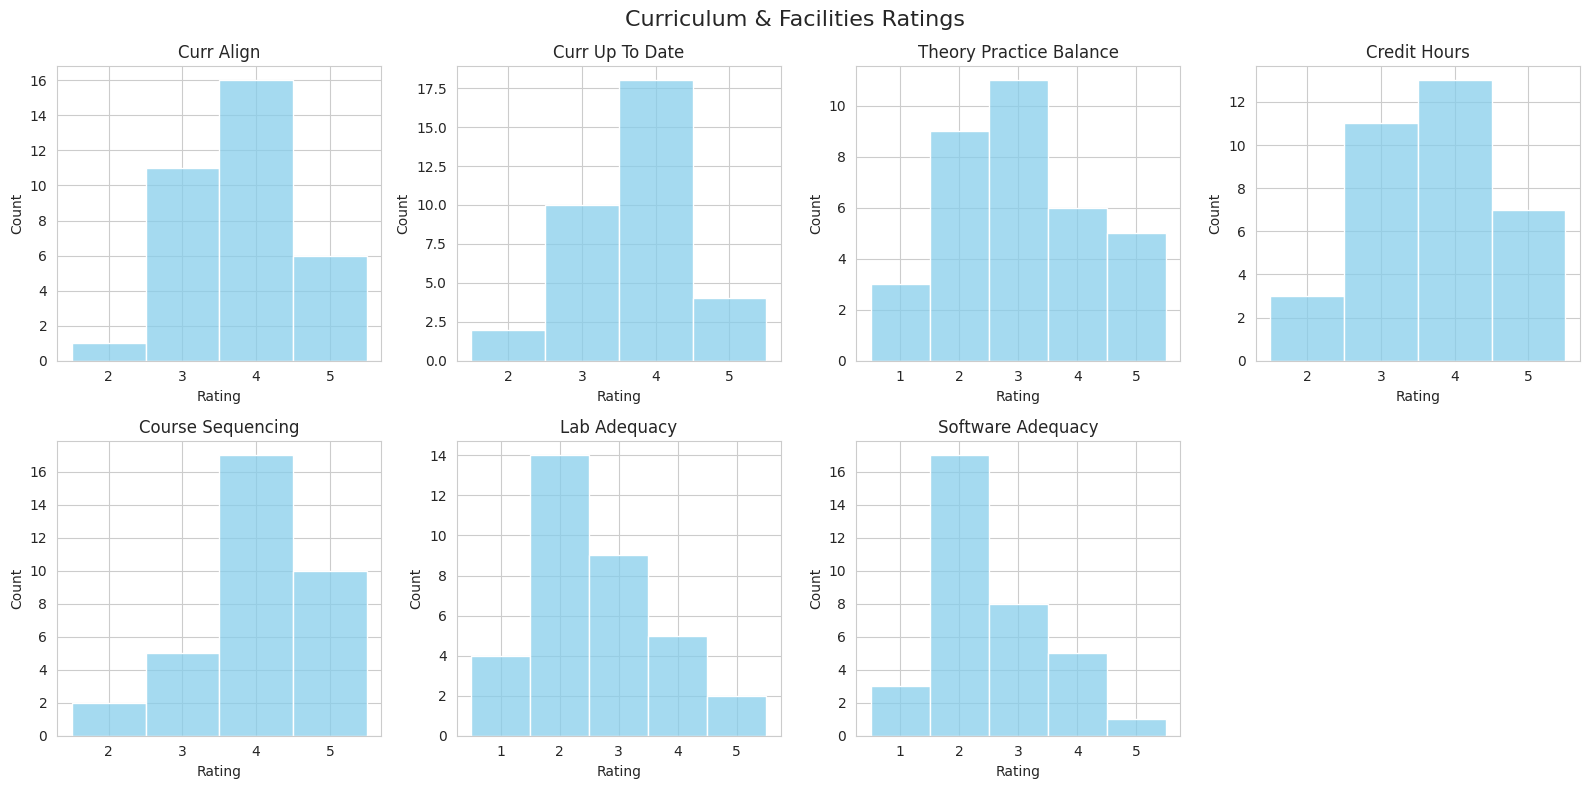

In [50]:

# 5. Visualizations

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 5.1 Distribution of curriculum ratings
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(rating_cols[:7]):
    sns.histplot(df[col].dropna(), bins=5, discrete=True, ax=axes[i], color='skyblue')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Rating')
    axes[i].set_ylabel('Count')
axes[-1].axis('off')  # hide extra subplot
plt.suptitle('Curriculum & Facilities Ratings', fontsize=16)
plt.tight_layout()
plt.savefig('curriculum_ratings.png', dpi=150)
plt.show()

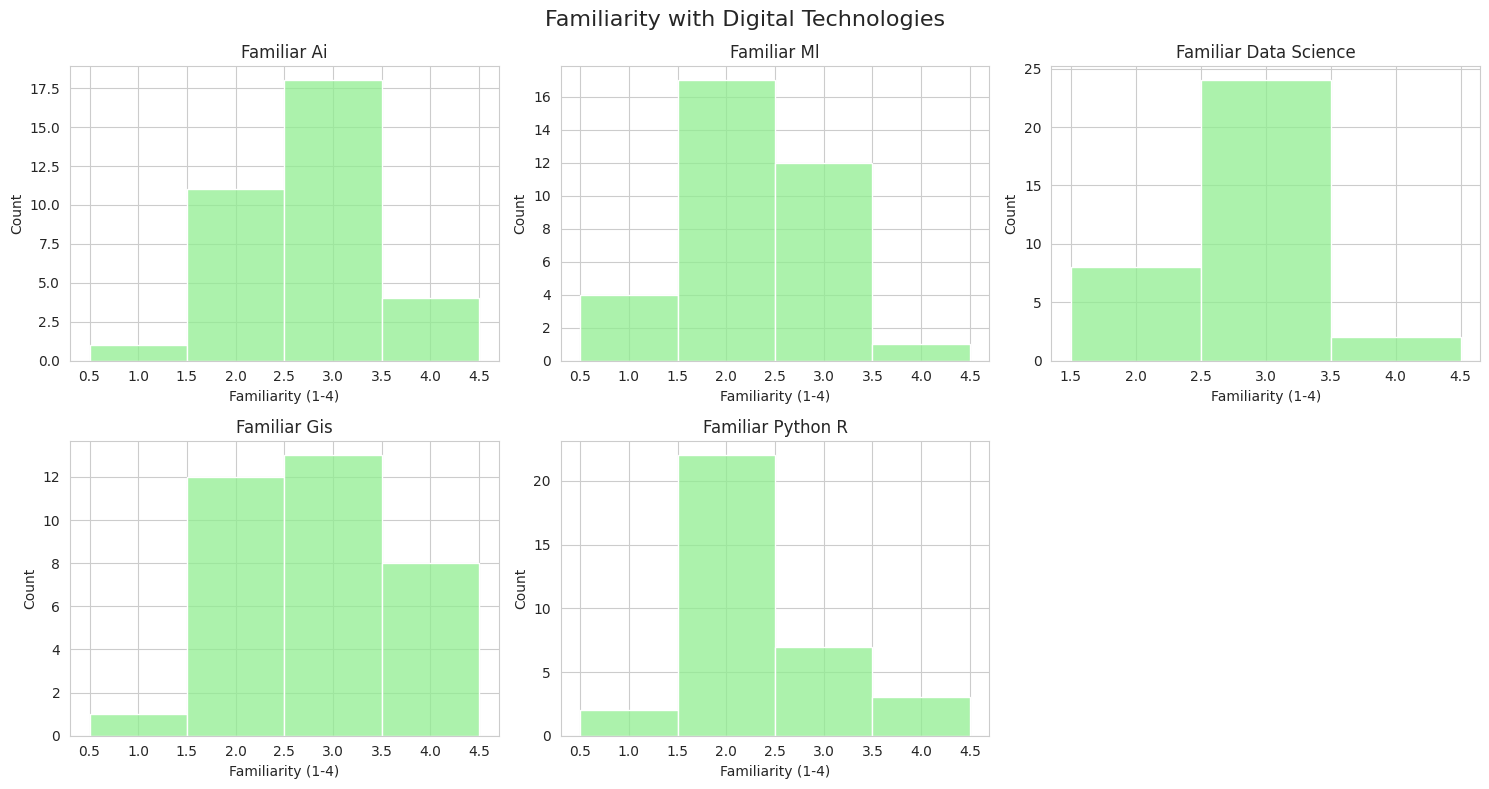

In [51]:
# 5.2 Familiarity with digital technologies
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(rating_cols[7:12]):
    sns.histplot(df[col].dropna(), bins=4, discrete=True, ax=axes[i], color='lightgreen')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Familiarity (1-4)')
    axes[i].set_ylabel('Count')
axes[-1].axis('off')
plt.suptitle('Familiarity with Digital Technologies', fontsize=16)
plt.tight_layout()
plt.savefig('digital_familiarity.png', dpi=150)
plt.show()

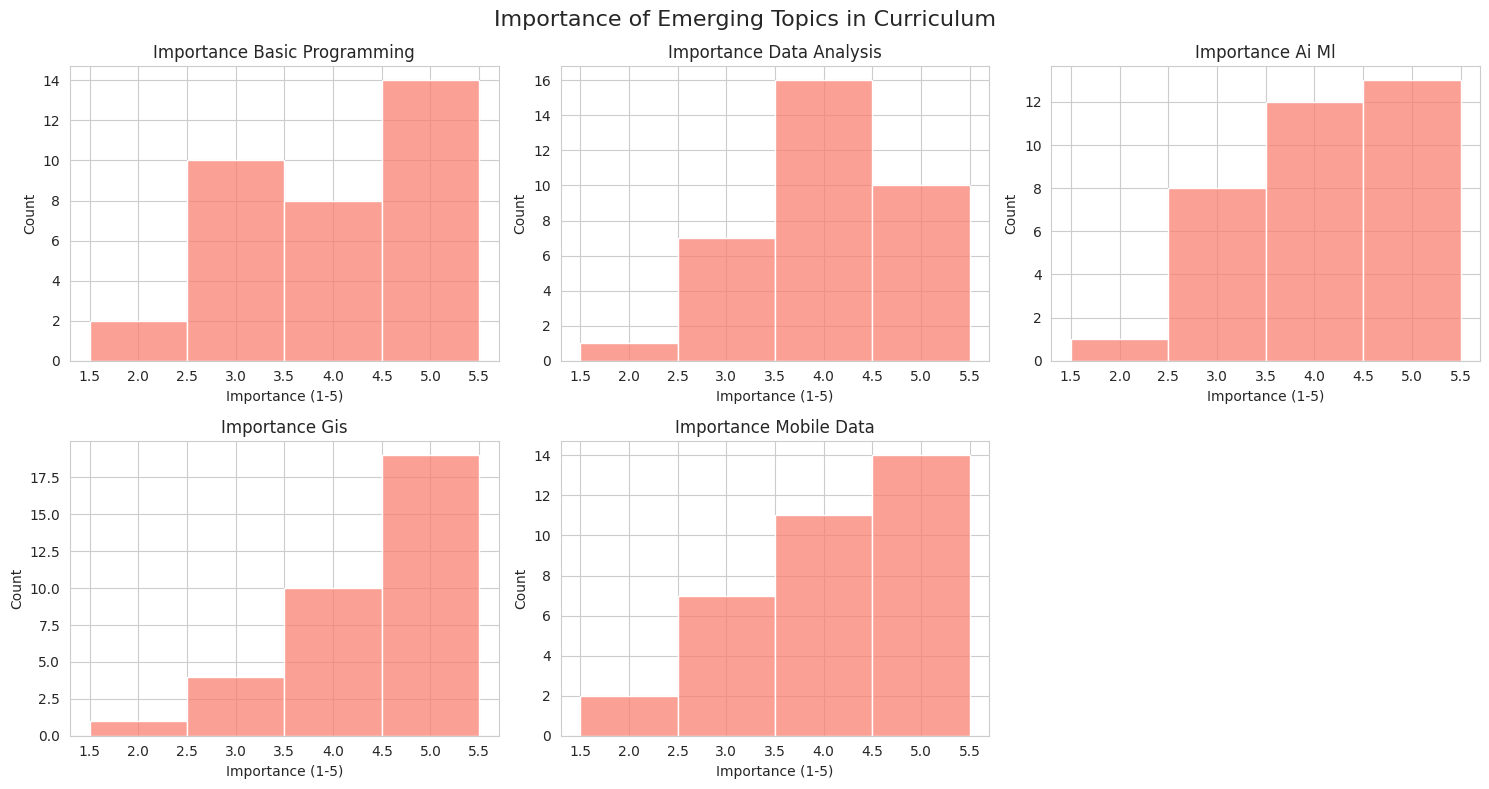

In [52]:
# 5.3 Importance of emerging topics
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(rating_cols[12:]):
    sns.histplot(df[col].dropna(), bins=5, discrete=True, ax=axes[i], color='salmon')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Importance (1-5)')
    axes[i].set_ylabel('Count')
axes[-1].axis('off')
plt.suptitle('Importance of Emerging Topics in Curriculum', fontsize=16)
plt.tight_layout()
plt.savefig('importance_topics.png', dpi=150)
plt.show()

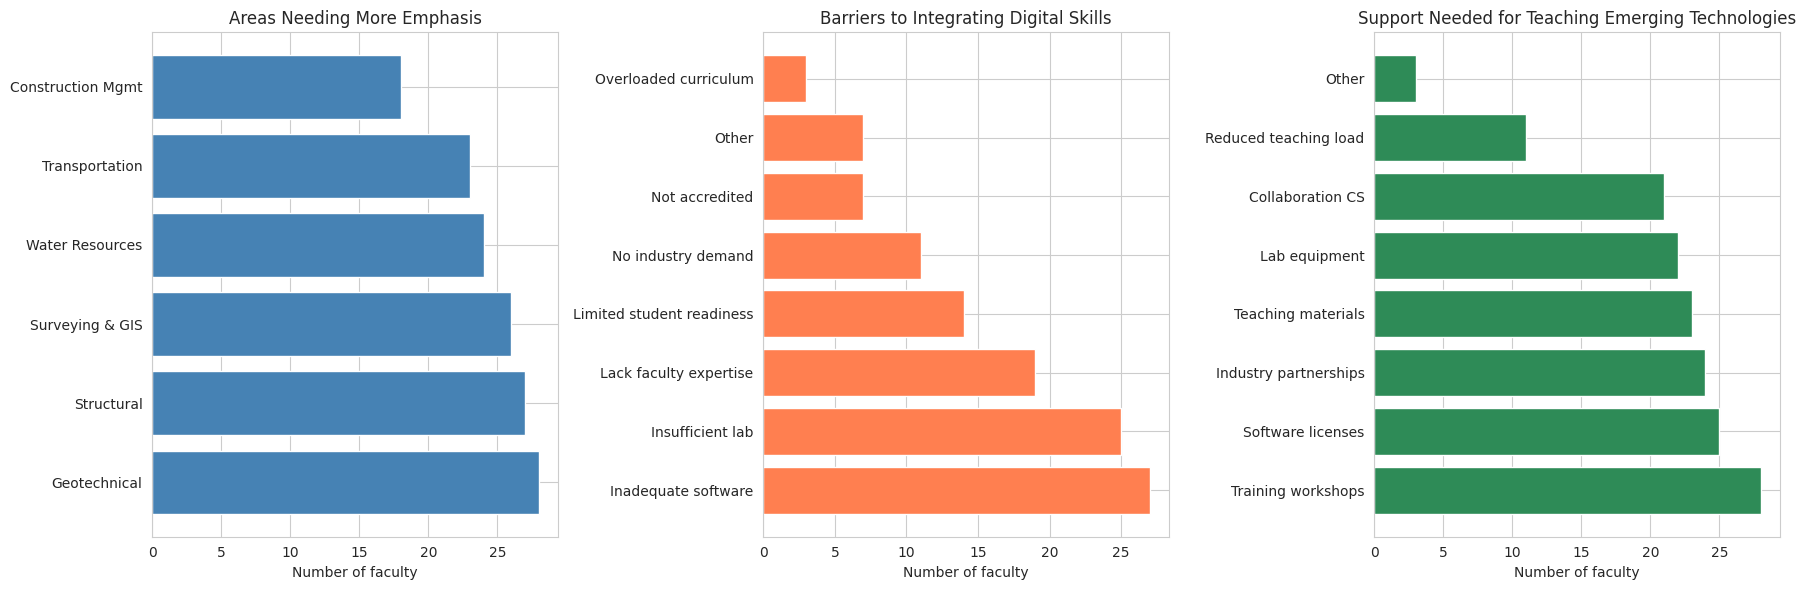

In [53]:
# 5.4 Bar plots for multiple-response questions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Create mappings from column names to display labels
emphasis_name_to_label = dict(zip(emphasis_cols, emphasis_labels))
barrier_name_to_label = dict(zip(barrier_cols, barrier_labels))
support_name_to_label = dict(zip(support_cols, support_labels))

# Areas needing emphasis
emphasis_display_labels = [emphasis_name_to_label[col_name] for col_name in emphasis_counts.index]
axes[0].barh(emphasis_display_labels, emphasis_counts.values, color='steelblue')
axes[0].set_title('Areas Needing More Emphasis')
axes[0].set_xlabel('Number of faculty')

# Barriers
barrier_display_labels = [barrier_name_to_label[col_name] for col_name in barrier_counts.index]
axes[1].barh(barrier_display_labels, barrier_counts.values, color='coral')
axes[1].set_title('Barriers to Integrating Digital Skills')
axes[1].set_xlabel('Number of faculty')

# Support needed
support_display_labels = [support_name_to_label[col_name] for col_name in support_counts.index]
axes[2].barh(support_display_labels, support_counts.values, color='seagreen')
axes[2].set_title('Support Needed for Teaching Emerging Technologies')
axes[2].set_xlabel('Number of faculty')

plt.tight_layout()
plt.savefig('multiple_response.png', dpi=150)
plt.show()

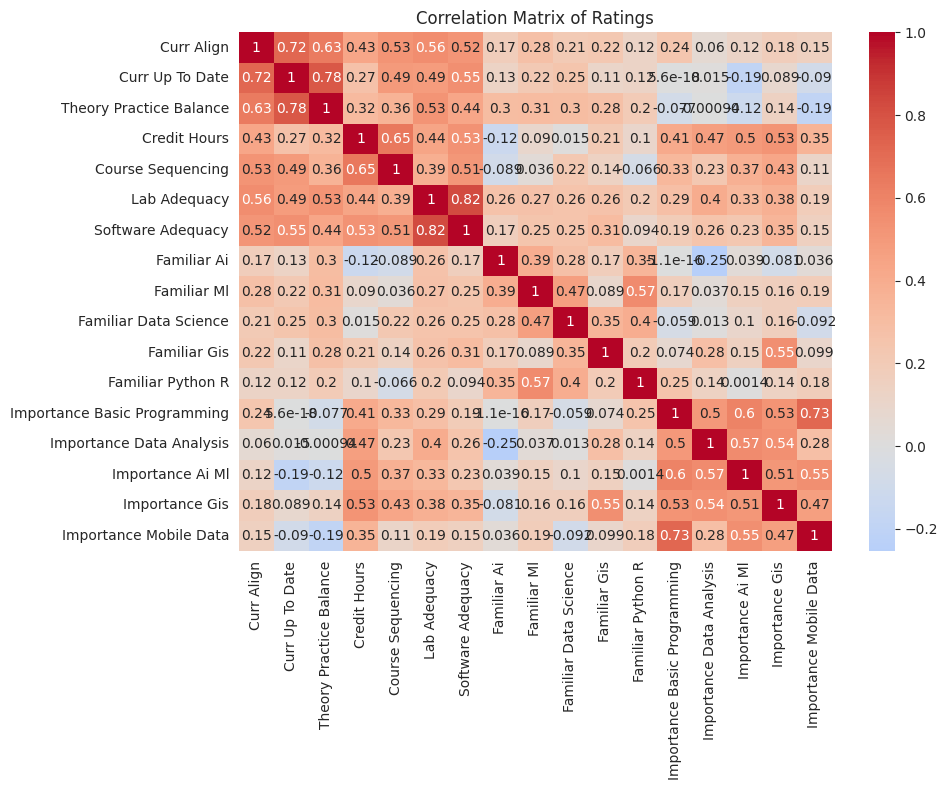

In [54]:
# 5.5 Correlation heatmap of ratings
corr = df[rating_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            xticklabels=[c.replace('_', ' ').title() for c in rating_cols],
            yticklabels=[c.replace('_', ' ').title() for c in rating_cols])
plt.title('Correlation Matrix of Ratings')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [55]:
# 6. Cross-tabulations and Group Comparisons

# 6.1 Average ratings by specialization (top specializations)
top_specs = df['specialization'].value_counts().head(6).index
spec_avg = df[df['specialization'].isin(top_specs)].groupby('specialization')[rating_cols[:7]].mean()
print("\n--- Average Curriculum Ratings by Specialization (top 6) ---")
print(spec_avg.round(2))


--- Average Curriculum Ratings by Specialization (top 6) ---
                                curr_align  curr_up_to_date  \
specialization                                                
Geotechnical Engineering              3.67             3.67   
Geotechnical engineering              3.50             3.50   
Hydraulic Engineering                 4.00             4.00   
Road and Transport Engineering        2.50             2.50   
Structural Engineering                3.83             3.67   
Structural engineer                   4.00             4.00   

                                theory_practice_balance  credit_hours  \
specialization                                                          
Geotechnical Engineering                           2.33          3.00   
Geotechnical engineering                           2.50          4.00   
Hydraulic Engineering                              3.67          3.67   
Road and Transport Engineering                     1.50          4.0

In [56]:
# 6.2 Average familiarity by specialization
familiar_avg = df[df['specialization'].isin(top_specs)].groupby('specialization')[rating_cols[7:12]].mean()
print("\n--- Average Digital Familiarity by Specialization ---")
print(familiar_avg.round(2))


--- Average Digital Familiarity by Specialization ---
                                familiar_ai  familiar_ml  \
specialization                                             
Geotechnical Engineering               2.67          2.0   
Geotechnical engineering               2.50          2.0   
Hydraulic Engineering                  3.00          2.0   
Road and Transport Engineering         2.00          2.0   
Structural Engineering                 2.67          2.5   
Structural engineer                    2.50          2.5   

                                familiar_data_science  familiar_gis  \
specialization                                                        
Geotechnical Engineering                         2.67          2.67   
Geotechnical engineering                         2.50          2.50   
Hydraulic Engineering                            3.00          3.33   
Road and Transport Engineering                   3.00          2.50   
Structural Engineering                

In [57]:
# 6.3 Importance ratings by experience group
exp_groups = df['experience_clean'].dropna().unique()
imp_by_exp = df.groupby('experience_clean')[rating_cols[12:]].mean()
print("\n--- Importance of Emerging Topics by Experience ---")
print(imp_by_exp.round(2))


--- Importance of Emerging Topics by Experience ---
                  importance_basic_programming  importance_data_analysis  \
experience_clean                                                           
5-10 years                                4.07                      3.87   
>10 years                                 3.95                      4.16   

                  importance_ai_ml  importance_gis  importance_mobile_data  
experience_clean                                                            
5-10 years                    4.07            4.47                    4.40  
>10 years                     4.11            4.32                    3.84  


In [58]:
# 6.4 Assessment methods vs. ratings
print("\n--- Assessment Methods Distribution ---")
print(df['assessment_clean'].value_counts())
# Compare curriculum ratings for 'Yes' vs 'Partially' vs 'No'
assess_groups = df.groupby('assessment_clean')[rating_cols[:5]].mean()
print("\n--- Average Curriculum Ratings by Assessment Method Response ---")
print(assess_groups.round(2))


--- Assessment Methods Distribution ---
assessment_clean
yes          19
partially    15
Name: count, dtype: int64

--- Average Curriculum Ratings by Assessment Method Response ---
                  curr_align  curr_up_to_date  theory_practice_balance  \
assessment_clean                                                         
partially               3.40             3.27                     2.47   
yes                     4.11             4.05                     3.47   

                  credit_hours  course_sequencing  
assessment_clean                                   
partially                 3.67               3.80  
yes                       3.74               4.21  


In [59]:
# ------------------------------
# 7. Key Insights Summary
# ------------------------------
print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)

print("""
- The majority of faculty are Lecturers with >10 years or 5-10 years experience.
- Curriculum alignment and course sequencing are rated relatively high (mean > 4),
  but balance between theory and practice and software adequacy are rated lower.
- Geotechnical, Structural, and Surveying & GIS are the areas most frequently
  cited as needing more emphasis.
- Familiarity with digital tools is moderate; GIS is best known, AI/ML least.
- The most significant barriers are insufficient lab facilities, inadequate software,
  and lack of faculty expertise.
- Training workshops, software licenses, and lab equipment are the top requested supports.
- Most faculty prefer integrating digital skills into existing courses rather than
  separate courses or workshops.
- Importance ratings for emerging topics are high (mostly >4), indicating strong
  support for including them in the curriculum.
""")


KEY INSIGHTS

- The majority of faculty are Lecturers with >10 years or 5-10 years experience.
- Curriculum alignment and course sequencing are rated relatively high (mean > 4),
  but balance between theory and practice and software adequacy are rated lower.
- Geotechnical, Structural, and Surveying & GIS are the areas most frequently
  cited as needing more emphasis.
- Familiarity with digital tools is moderate; GIS is best known, AI/ML least.
- The most significant barriers are insufficient lab facilities, inadequate software,
  and lack of faculty expertise.
- Training workshops, software licenses, and lab equipment are the top requested supports.
- Most faculty prefer integrating digital skills into existing courses rather than
  separate courses or workshops.
- Importance ratings for emerging topics are high (mostly >4), indicating strong
  support for including them in the curriculum.

